# Node Embeddings for TypeScript

This notebook demonstrates different methods for node embeddings and how to further reduce their dimensionality to be able to visualize them in a 2D plot. 

Node embeddings are essentially an array of floating point numbers (length = embedding dimension) that can be used as "features" in machine learning. These numbers approximate the relationship and similarity information of each node and can also be seen as a way to encode the topology of the graph.

## Considerations

Due to dimensionality reduction some information gets lost, especially when visualizing node embeddings in two dimensions. Nevertheless, it helps to get an intuition on what node embeddings are and how much of the similarity and neighborhood information is retained. The latter can be observed by how well nodes of the same color and therefore same community are placed together and how much bigger nodes with a high centrality score influence them. 

If the visualization doesn't show a somehow clear separation between the communities (colors) here are some ideas for tuning: 
- Clean the data, e.g. filter out very few nodes with extremely high degree that aren't actually that important
- Try directed vs. undirected projections
- Tune the embedding algorithm, e.g. use a higher dimensionality
- Tune UMAP that is used to reduce the node embeddings dimension to two dimensions for visualization. 

It could also be the case that the node embeddings are good enough and well suited the way they are despite their visualization for the down stream task like node classification or link prediction. In that case it makes sense to see how the whole pipeline performs before tuning the node embeddings in detail. 

## Note about data dependencies

PageRank centrality and Leiden community are also fetched from the Graph and need to be calculated first.
This makes it easier to see if the embeddings approximate the structural information of the graph in the plot.
If these properties are missing you will only see black dots all of the same size.

<br>  

### References
- [jqassistant](https://jqassistant.org)
- [Neo4j Python Driver](https://neo4j.com/docs/api/python-driver/current)
- [Tutorial: Applied Graph Embeddings](https://neo4j.com/developer/graph-data-science/applied-graph-embeddings)
- [Visualizing the embeddings in 2D](https://github.com/openai/openai-cookbook/blob/main/examples/Visualizing_embeddings_in_2D.ipynb)
- [UMAP](https://umap-learn.readthedocs.io/en/latest)
- [AttributeError: 'list' object has no attribute 'shape'](https://bobbyhadz.com/blog/python-attributeerror-list-object-has-no-attribute-shape)
- [Fast Random Projection (neo4j)](https://neo4j.com/docs/graph-data-science/current/machine-learning/node-embeddings/fastrp)
- [HashGNN (neo4j)](https://neo4j.com/docs/graph-data-science/2.6/machine-learning/node-embeddings/hashgnn)
- [node2vec (neo4j)](https://neo4j.com/docs/graph-data-science/current/machine-learning/node-embeddings/node2vec) computes a vector representation of a node based on second order random walks in the graph. 
- [Complete guide to understanding Node2Vec algorithm](https://towardsdatascience.com/complete-guide-to-understanding-node2vec-algorithm-4e9a35e5d147)

In [1]:
%%html
<style>
/* CSS style for smaller dataframe tables. */
.dataframe th {
    font-size: 8px;
}
.dataframe td {
    font-size: 8px;
}
</style>

In [2]:
import os
from IPython.display import display
import pandas as pd
import matplotlib.pyplot as plot
import typing as typ
import numpy as np
import umap
from neo4j import GraphDatabase
from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score

In [3]:
print('The numpy version is: {}'.format(np.__version__))
print('The pandas version is: {}'.format(pd.__version__))

from matplotlib import __version__ as matplotlib_version
print('The matplotlib version is: {}'.format(matplotlib_version))

from sklearn import __version__ as sklearn_version
print('The sklearn version is: {}'.format(sklearn_version))

from umap import __version__ as umap_version
print('The UMAP version is: {}'.format(umap_version))

The numpy version is: 1.26.4
The pandas version is: 2.2.3
The matplotlib version is: 3.10.8
The sklearn version is: 1.6.1
The UMAP version is: 0.5.9.post2


In [4]:
# Please set the environment variable "NEO4J_INITIAL_PASSWORD" in your shell 
# before starting jupyter notebook to provide the password for the user "neo4j". 
# It is not recommended to hardcode the password into jupyter notebook for security reasons.

driver = GraphDatabase.driver(uri="bolt://localhost:7687", auth=("neo4j", os.environ.get("NEO4J_INITIAL_PASSWORD")))
driver.verify_connectivity()

In [5]:
def get_cypher_query_from_file(filename):
    with open(filename) as file:
        return ' '.join(file.readlines())
    

def query_cypher_to_data_frame(filename, parameters_: typ.Optional[typ.Dict[str, typ.Any]] = None):
    records, summary, keys = driver.execute_query(get_cypher_query_from_file(filename),parameters_=parameters_)
    return pd.DataFrame([r.values() for r in records], columns=keys)


def query_first_non_empty_cypher_to_data_frame(*filenames : str, parameters: typ.Optional[typ.Dict[str, typ.Any]] = None):
    """
    Executes the Cypher queries of the given files and returns the first result that is not empty.
    If all given file names result in empty results, the last (empty) result will be returned.
    By additionally specifying "limit=" the "LIMIT" keyword will appended to query so that only the first results get returned.
    """
    result=pd.DataFrame()
    for filename in filenames:
        result=query_cypher_to_data_frame(filename, parameters)
        if not result.empty:
            print("The results have been provided by the query filename: " + filename)
            return result
    return result

In [6]:
def create_undirected_projection(parameters: dict) -> bool: 
    """
    Creates an undirected homogenous in-memory Graph projection for/with Neo4j Graph Data Science Plugin.
    It returns True if there is data available for the given parameter and False otherwise.
    Parameters
    ----------
    dependencies_projection : str
        The name prefix for the in-memory projection for dependencies. Example: "java-package-embeddings-notebook"
    dependencies_projection_node : str
        The label of the nodes that will be used for the projection. Example: "Package"
    dependencies_projection_weight_property : str
        The name of the node property that contains the dependency weight. Example: "weight25PercentInterfaces"
    dependencies_projection_embedding_dimension : str
        The number of the dimensions and therefore size of the resulting array of floating point numbers
    """
    
    is_data_missing=query_cypher_to_data_frame("../cypher/Dependencies_Projection/Dependencies_0_Check_Projectable.cypher", parameters).empty
    if is_data_missing: return False

    query_cypher_to_data_frame("../cypher/Dependencies_Projection/Dependencies_1_Delete_Projection.cypher", parameters)
    query_cypher_to_data_frame("../cypher/Dependencies_Projection/Dependencies_2_Delete_Subgraph.cypher", parameters)
    # To include the direction of the relationships use the following line to create the projection:
    # query_cypher_to_data_frame("../cypher/Dependencies_Projection/Dependencies_3_Create_Projection.cypher", parameters)
    query_cypher_to_data_frame("../cypher/Dependencies_Projection/Dependencies_4_Create_Undirected_Projection.cypher", parameters)
    query_cypher_to_data_frame("../cypher/Dependencies_Projection/Dependencies_5_Create_Subgraph.cypher", parameters)
    return True

In [7]:
def get_projected_graph_statistics(projection_name: str) -> pd.DataFrame:
    """
    Returns the projection statistics for the given parameters.
    Parameters
    ----------
    projection_name : str
        The name prefix for the in-memory projection for dependencies. Example: "java-package-embeddings-notebook"
    """

    parameters = dict(
        dependencies_projection=projection_name,
    )
    return query_cypher_to_data_frame("../cypher/Dependencies_Projection/Dependencies_12_Get_Projection_Statistics.cypher", parameters)


def get_projected_graph_node_count(projection_name: str) -> int:
    """
    Returns the number of nodes in the projected graph.
    Parameters
    ----------
    projection_name : str
        The name prefix for the in-memory projection for dependencies. Example: "java-package-embeddings-notebook"
    """

    graph_statistics = get_projected_graph_statistics(projection_name)
    if graph_statistics.empty:
        return 0
    return graph_statistics["nodeCount"].values[0]

In [8]:
def empty_embeddings() -> pd.DataFrame:
    return pd.DataFrame(columns=["codeUnitName", "shortCodeUnitName", 'projectName', 'communityId', 'centrality', 'embedding', 'x', 'y'])

In [9]:
# Feature Ideas:
# - Option to choose between directed and undirected projection?
# - Option to not read already existing node embeddings to experiment with different hyper-parameters?
# - Run a community detection algorithm co-located in here when "communityId" is missing?
# - Run a centrality algorithm co-located in here when "centrality" score is missing?

def create_node_embeddings(cypher_file_name: str, parameters: dict) -> pd.DataFrame: 
    """
    Creates an in-memory Graph projection by calling "create_undirected_projection", 
    runs the cypher Query given as cypherFileName parameter to calculate and stream the node embeddings
    and returns a DataFrame with the results.
    
    cypher_file_name
    ----------
    Name of the file containing the Cypher query that executes node embeddings procedure.

    parameters
    ----------
    dependencies_projection : str
        The name prefix for the in-memory projection for dependencies. Example: "typescript-module-embeddings-notebook"
    dependencies_projection_node : str
        The label of the nodes that will be used for the projection. Example: "Module"
    dependencies_projection_weight_property : str
        The name of the node property that contains the dependency weight. Example: "lowCouplingElement25PercentWeight"
    dependencies_projection_embedding_dimension : str
        The number of the dimensions and therefore size of the resulting array of floating point numbers
    dependencies_projection_write_property : str
        The name of the node property where the resulting embeddings will be stored. Example: "embedding
    """
    
    node_count = get_projected_graph_node_count(parameters["dependencies_projection"])
    if node_count <= 0:
        print("No projected data for node embeddings calculation available")
        return empty_embeddings()

    existing_embeddings_query_filename="../cypher/Node_Embeddings/Node_Embeddings_0a_Query_Calculated.cypher"
    embeddings = query_first_non_empty_cypher_to_data_frame(existing_embeddings_query_filename, cypher_file_name, parameters=parameters)
    display(embeddings.head()) # Display the first entries of the table
    return embeddings

In [10]:
def create_node_embeddings_with_GraphSAGE(parameters: dict) -> pd.DataFrame: 
    """
    Creates an in-memory Graph projection by calling "create_undirected_projection", 
    enriches it with a degree centrality property for every node, trains GraphSAGE 
    and returns the resulting node embeddings as DataFrame.
    
    parameters
    ----------
    dependencies_projection : str
        The name prefix for the in-memory projection for dependencies. Example: "java-package-embeddings-notebook"
    dependencies_projection_node : str
        The label of the nodes that will be used for the projection. Example: "Package"
    dependencies_projection_weight_property : str
        The name of the node property that contains the dependency weight. Example: "weight25PercentInterfaces"
    dependencies_projection_embedding_dimension : str
        The number of the dimensions and therefore size of the resulting array of floating point numbers
    """
    
    node_count = get_projected_graph_node_count(parameters["dependencies_projection"])
    if node_count <= 0:
        print("No projected data for node embeddings calculation available")
        return empty_embeddings()
    
    if node_count > 500:
        print("GraphSAGE node embeddings training will be skipped for " + str(node_count) + " (>500) nodes, since it is computationally expensive and not eagerly needed for demonstration purposes.")
        return empty_embeddings()
    
    query_cypher_to_data_frame("../cypher/Node_Embeddings/Node_Embeddings_0b_Prepare_Degree.cypher", parameters)
    query_cypher_to_data_frame("../cypher/Node_Embeddings/Node_Embeddings_0c_Drop_Model.cypher", parameters)
    display(query_cypher_to_data_frame("../cypher/Node_Embeddings/Node_Embeddings_4b_GraphSAGE_Train.cypher", parameters))
    embeddings=query_cypher_to_data_frame("../cypher/Node_Embeddings/Node_Embeddings_4d_GraphSAGE_Stream.cypher", parameters)
    
    display(embeddings.head()) # Display the first entries of the table
    return embeddings

In [11]:
class CommunityScores:
    
    def __init__(self, silhouette_score: float, davies_bouldin_score: float):
        self.silhouette_score = silhouette_score
        self.davies_bouldin_score = davies_bouldin_score

    def __repr__(self):
        return f"CommunityScores(silhouette_score={self.silhouette_score}, davies_bouldin_score={self.davies_bouldin_score})"

    @classmethod
    def calculate(cls, data: pd.DataFrame, metric: str = "cosine"):
        """
        data: pandas DataFrame with columns:
            - 'communityId': int
            - 'embedding': array-like (same length for all rows)
        metric: 'cosine', 'euclidean', etc.
        """
        # ensure we pass a sequence/array of arrays to sklearn / numpy
        X = np.array(data["embedding"].to_list())
        labels = data["communityId"].astype(int)

        if len(np.unique(labels)) < 2:
            print("Community scores require at least 2 communities")
            return cls(0.0, 0.0)

        silhouette = silhouette_score(X, labels, metric=metric)
        davies_bouldin = davies_bouldin_score(X, labels)
        return cls(float(silhouette), float(davies_bouldin))

In [12]:
def prepare_node_embeddings_for_2d_visualization(embeddings: pd.DataFrame) -> pd.DataFrame:
    """
    Reduces the dimensionality of the node embeddings (e.g. 64 floating point numbers in an array)
    to two dimensions for 2D visualization using Uniform Manifold Approximation and Projection (UMAP).
    see https://umap-learn.readthedocs.io
    """

    if embeddings.empty:
        print("No projected data for node embeddings dimensionality reduction available with UMAP.")
        return embeddings

    # Convert the list of embeddings to a numpy array
    embeddings_as_numpy_array = np.array(embeddings.embedding.to_list())

    # Use UMAP to reduce the dimensionality to 2D for visualization
    reducer = umap.UMAP(n_components=2, min_dist=0.3, random_state=42, n_jobs=1, verbose=False)
    two_dimensional_node_embeddings = reducer.fit_transform(embeddings_as_numpy_array)
    
    # Convert to dense numpy array (works for both sparse and dense input)
    two_dimensional_node_embeddings = np.asarray(two_dimensional_node_embeddings)
    # display(two_dimensional_node_embeddings.shape) # Display the shape of the UMAP result

    # Create a new DataFrame with the results of the 2 dimensional node embeddings
    # and the code unit and artifact name of the query above as preparation for the plot
    embeddings["x"] = [value[0] for value in two_dimensional_node_embeddings]
    embeddings["y"] = [value[1] for value in two_dimensional_node_embeddings]
    # display(embeddings.head()) # Display the first line of the results
    
    return embeddings

In [13]:
def find_community_medoids(
    data: pd.DataFrame,
    community_column_name: str = "communityId",
    x_column_name: str = "x",
    y_column_name: str = "y",
) -> pd.DataFrame:
    """
    Return one representative (geometric, less prone to outliers medoid) row per community.
    The medoid is defined as the point closest to the community centroid.

    Parameters
    ----------
    data : pd.DataFrame
        Input dataframe containing embeddings
    community_column_name : str
        Column identifying communities
    x_column_name, y_column_name : str
        Coordinate columns

    Returns
    -------
    pd.DataFrame
        Subset of df with one row per community (the medoids)
    """
    medoids = []

    for _, group in data.groupby(community_column_name):
        center_x = group[x_column_name].median()
        center_y = group[y_column_name].median()

        distances = (group[x_column_name] - center_x) ** 2 + (group[y_column_name] - center_y) ** 2
        medoid_index = distances.idxmin()

        medoids.append(data.loc[medoid_index])

    return pd.DataFrame(medoids).reset_index(drop=True)


In [14]:
def find_top_k_community_medoids(data, k=20, **kwargs):
    top_communities = (
        data.groupby("communityId")
        .size()
        .nlargest(k)
        .index
    )
    return find_community_medoids(
        data[data.communityId.isin(top_communities)],
        **kwargs
    )

In [15]:
plot_annotation_style: dict = {
    'textcoords': 'offset points',
    'arrowprops': dict(arrowstyle='->', color='black', alpha=0.3),
    'fontsize': 6,
    'backgroundcolor': 'white',
    'bbox': dict(boxstyle='round,pad=0.3',
                    edgecolor='silver',
                    facecolor='whitesmoke',
                    alpha=0.8
                )
}

In [16]:
def get_plot_title(code_unit_type:str, algorithm_name: str, scores: CommunityScores) -> str:
    main_title = f"{code_unit_type} dependency graph node embeddings"
    scores_description = f"Silhouette Score (aim higher)={scores.silhouette_score:.4f}, Davies-Bouldin Score (aim lower)={scores.davies_bouldin_score:.4f}"
    algorithm_description = f"{algorithm_name} -> UMAP"
    return f"{main_title}\n{scores_description}\n{algorithm_description}"

In [17]:
def plot_2d_node_embeddings_on_axes(axes: plot.Axes, embeddings: pd.DataFrame, title: str):
    if embeddings.empty:
        print("No projected data to plot available")
        return
    
    def normalize(values: pd.Series) -> pd.Series:
        max_value = values.max()
        min_value = values.min()
        range_value = max_value - min_value
        return (values - min_value) / range_value if range_value != 0 else values

    normalized_centrality = normalize(embeddings.centrality)
    base_size = np.clip(normalized_centrality * 50, None, 30) + 2

    common_parameters = {
        'x': embeddings.x,
        'y': embeddings.y,
        'c': embeddings.communityId,
        'cmap': 'nipy_spectral', # nipy_spectral, gist_ncar, jet, turbo, gist_stern, rainbow, viridis
        'linewidths': 1,
    }
    
    # Transparent 'halo' around the main points
    axes.scatter(
        **common_parameters,
        s=base_size * 6 + 12,
        alpha=0.12,
    )

    # Main points
    axes.scatter(
        **common_parameters,
        s=base_size,
        alpha=1.0
    )
    
    # Annotate medoids (representative points of communities, the node closest to the community center)
    medoids = find_top_k_community_medoids(embeddings)
    for _, row in medoids.iterrows():
        axes.annotate(
            f"{row.shortCodeUnitName}({row.communityId})",
            (row.x, row.y),
            xytext=(5, 5),
            **plot_annotation_style,
        )
    
    # Annotate top centrality nodes
    top_centrality_nodes = embeddings.nlargest(5, 'centrality')
    for _, row in top_centrality_nodes.iterrows():
        axes.annotate(
            row.shortCodeUnitName,
            (row.x, row.y),
            xytext=(5, 5),
            color='grey',
            **plot_annotation_style,
        )

    # Finalize plot
    axes.set_title(title, fontsize=9)
    axes.set_xticks([])
    axes.set_yticks([])

In [18]:
def plot_2d_node_embeddings(embeddings: pd.DataFrame, title: str, **kwargs):
    if embeddings.empty:
        print("No projected data to plot available")
        return
    
    figure, axes = plot.subplots(figsize=(8, 6))
    plot_2d_node_embeddings_on_axes(axes=axes, embeddings=embeddings, title=title, **kwargs)
    plot.tight_layout()
    plot.show()

In [19]:
def plot_all_2d_node_embeddings_in_grid(
    embeddings: typ.List[pd.DataFrame],
    titles: typ.List[str],
    number_of_columns: int = 2
):
    if embeddings[0].empty:
        print("No projected data to plot available")
        return
    
    number_of_rows = (len(embeddings) + number_of_columns - 1) // number_of_columns
    figure, axes = plot.subplots(number_of_rows, number_of_columns, figsize=(6 * number_of_columns, 4.5 * number_of_rows))
    axes = np.array(axes).flatten()
    i = -1

    for i, (node_embeddings_for_visualization, title) in enumerate(zip(embeddings, titles)):
        plot_2d_node_embeddings_on_axes(axes=axes[i], embeddings=node_embeddings_for_visualization, title=title)

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plot.tight_layout()
    plot.show()

In [20]:
#The following cell uses the build-in %html "magic" to override the CSS style for tables to a much smaller size.
#This is especially needed for PDF export of tables with multiple columns.

In [21]:
%%html
<style>
/* CSS style for smaller dataframe tables. */
.dataframe th {
    font-size: 8px;
}
.dataframe td {
    font-size: 8px;
}
</style>

## 1. Typescript Modules

### 1.1 Create Dependency Graph Projection for TypeScript Modules

The projection and related common parameters are shared across all embedding algorithms below.

In [22]:
common_projection_parameters={
    "dependencies_projection": "typescript-module-embeddings-notebook",
    "dependencies_projection_node": "Module",
    "dependencies_projection_weight_property": "lowCouplingElement25PercentWeight",
}
if create_undirected_projection(common_projection_parameters):
    display(get_projected_graph_statistics(common_projection_parameters["dependencies_projection"]))
else:
    print(f"No data for projection creation available: {common_projection_parameters}")

,nodeCount,relationshipCount,density,sizeInBytes,degreeDistribution.min,degreeDistribution.mean,degreeDistribution.max,degreeDistribution.p50,degreeDistribution.p75,degreeDistribution.p90,degreeDistribution.p95,degreeDistribution.p99,degreeDistribution.p999
0,129,680,0.041182,2597818,0,5.271318,60,3,6,11,15,27,60


### 1.2 Generate Node Embeddings for Typescript Modules using Fast Random Projection (Fast RP)

[Fast Random Projection](https://neo4j.com/docs/graph-data-science/current/machine-learning/node-embeddings/fastrp) is used to reduce the dimensionality of the node feature space while preserving most of the distance information. Nodes with similar neighborhood result in node embedding with similar vectors.

**👉 Hint:** To skip existing node embeddings and always calculate them based on the parameters below edit `Node_Embeddings_0a_Query_Calculated` so that it won't return any results.

In [23]:
typescript_module_embeddings_parameters={
    **common_projection_parameters,
    "dependencies_projection_write_property": "embeddingsFastRandomProjection",
    "dependencies_projection_embedding_dimension":"32" 
}
embeddings_fastRP = create_node_embeddings("../cypher/Node_Embeddings/Node_Embeddings_1d_Fast_Random_Projection_Stream.cypher", typescript_module_embeddings_parameters)


Received notification from DBMS server: {severity: WARNING} {code: Neo.ClientNotification.Statement.UnknownLabelWarning} {category: UNRECOGNIZED} {title: The provided label is not in the database.} {description: One of the labels in your query is not available in the database, make sure you didn't misspell it or that the label is available when you run this statement in your application (the missing label name is: Java)} {position: line: 7, column: 27, offset: 572} for query: '// Query already calculated and written node embeddings on nodes with label in parameter $dependencies_projection_node including a communityId and centrality. Variables: dependencies_projection_node, dependencies_projection_write_property. Requires "Add_file_name and_extension.cypher".\n \n  MATCH (codeUnit)\n  WHERE $dependencies_projection_node IN LABELS(codeUnit)\n    AND codeUnit[$dependencies_projection_write_property] IS NOT NULL\n    // AND codeUnit.notExistingToForceRecalculation IS NOT NULL // uncomment 

Received notification from DBMS server: {severity: WARNING} {code: Neo.ClientNotification.Statement.UnknownPropertyKeyWarning} {category: UNRECOGNIZED} {title: The provided property key is not in the database} {description: One of the property names in your query is not available in the database, make sure you didn't misspell it or that the label is available when you run this statement in your application (the missing property name is: signature)} {position: line: 12, column: 81, offset: 924} for query: '// Query already calculated and written node embeddings on nodes with label in parameter $dependencies_projection_node including a communityId and centrality. Variables: dependencies_projection_node, dependencies_projection_write_property. Requires "Add_file_name and_extension.cypher".\n \n  MATCH (codeUnit)\n  WHERE $dependencies_projection_node IN LABELS(codeUnit)\n    AND codeUnit[$dependencies_projection_write_property] IS NOT NULL\n    // AND codeUnit.notExistingToForceRecalculat

The results have been provided by the query filename: ../cypher/Node_Embeddings/Node_Embeddings_0a_Query_Calculated.cypher


,codeUnitName,shortCodeUnitName,projectName,communityId,centrality,embedding
0,/home/runner/work/code-graph-analysis-examples...,config,react-router-dev,0,1.705838,"[-0.5952500700950623, -0.3340594470500946, 0.1..."
1,/home/runner/work/code-graph-analysis-examples...,detectPackageManager,react-router-dev,0,0.188886,"[-0.6000653505325317, -0.32334285974502563, 0...."
2,/home/runner/work/code-graph-analysis-examples...,config,react-router-dev,0,2.129389,"[-0.5498749613761902, -0.38851770758628845, 0...."
3,/home/runner/work/code-graph-analysis-examples...,context,react-router-dev,0,0.180345,"[-0.3691451847553253, -0.6460049152374268, 0.3..."
4,/home/runner/work/code-graph-analysis-examples...,generate,react-router-dev,0,0.277201,"[-0.10859015583992004, -0.2827555537223816, -0..."


### 1.3 Dimensionality reduction with Uniform Manifold Approximation and Projection (UMAP)

This step takes the original node embeddings in their high dimensionality, e.g. 32 floating point numbers, and reduces them into a two dimensional array for visualization. For more details look up the function  "prepare_node_embeddings_for_2d_visualization".

**About UMAP:**

> The embedding is found by searching for a low dimensional projection of the data that has the closest possible equivalent fuzzy topological structure.

(see https://umap-learn.readthedocs.io)

In [24]:
embeddings_fastRP = prepare_node_embeddings_for_2d_visualization(embeddings_fastRP)
scores_fastRP = CommunityScores.calculate(embeddings_fastRP)

### 1.4 Plot the node embeddings reduced to two dimensions for Typescript

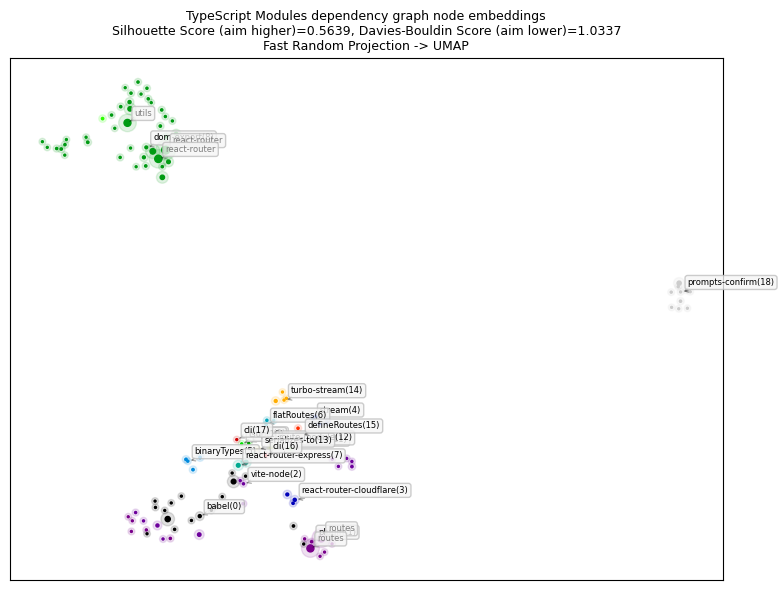

In [25]:
plot_2d_node_embeddings(embeddings_fastRP, get_plot_title("TypeScript Modules", "Fast Random Projection", scores_fastRP))

### 1.5 Node Embeddings for Typescript Modules using HashGNN

[HashGNN](https://neo4j.com/docs/graph-data-science/2.6/machine-learning/node-embeddings/hashgnn) resembles Graph Neural Networks (GNN) but does not include a model or require training. It combines ideas of GNNs and fast randomized algorithms. For more details see [HashGNN](https://neo4j.com/docs/graph-data-science/2.6/machine-learning/node-embeddings/hashgnn). Here, the latter 3 steps are combined into one for HashGNN.

Received notification from DBMS server: {severity: WARNING} {code: Neo.ClientNotification.Statement.UnknownLabelWarning} {category: UNRECOGNIZED} {title: The provided label is not in the database.} {description: One of the labels in your query is not available in the database, make sure you didn't misspell it or that the label is available when you run this statement in your application (the missing label name is: Java)} {position: line: 7, column: 27, offset: 572} for query: '// Query already calculated and written node embeddings on nodes with label in parameter $dependencies_projection_node including a communityId and centrality. Variables: dependencies_projection_node, dependencies_projection_write_property. Requires "Add_file_name and_extension.cypher".\n \n  MATCH (codeUnit)\n  WHERE $dependencies_projection_node IN LABELS(codeUnit)\n    AND codeUnit[$dependencies_projection_write_property] IS NOT NULL\n    // AND codeUnit.notExistingToForceRecalculation IS NOT NULL // uncomment 

Received notification from DBMS server: {severity: WARNING} {code: Neo.ClientNotification.Statement.UnknownPropertyKeyWarning} {category: UNRECOGNIZED} {title: The provided property key is not in the database} {description: One of the property names in your query is not available in the database, make sure you didn't misspell it or that the label is available when you run this statement in your application (the missing property name is: signature)} {position: line: 12, column: 81, offset: 924} for query: '// Query already calculated and written node embeddings on nodes with label in parameter $dependencies_projection_node including a communityId and centrality. Variables: dependencies_projection_node, dependencies_projection_write_property. Requires "Add_file_name and_extension.cypher".\n \n  MATCH (codeUnit)\n  WHERE $dependencies_projection_node IN LABELS(codeUnit)\n    AND codeUnit[$dependencies_projection_write_property] IS NOT NULL\n    // AND codeUnit.notExistingToForceRecalculat

The results have been provided by the query filename: ../cypher/Node_Embeddings/Node_Embeddings_0a_Query_Calculated.cypher


,codeUnitName,shortCodeUnitName,projectName,communityId,centrality,embedding
0,/home/runner/work/code-graph-analysis-examples...,config,react-router-dev,0,1.705838,"[1.8371173739433289, 1.530931144952774, 0.6123..."
1,/home/runner/work/code-graph-analysis-examples...,detectPackageManager,react-router-dev,0,0.188886,"[1.530931144952774, 0.3061862289905548, 0.6123..."
2,/home/runner/work/code-graph-analysis-examples...,config,react-router-dev,0,2.129389,"[2.1433036029338837, 1.2247449159622192, 0.612..."
3,/home/runner/work/code-graph-analysis-examples...,context,react-router-dev,0,0.180345,"[1.2247449159622192, 0.6123724579811096, 1.224..."
4,/home/runner/work/code-graph-analysis-examples...,generate,react-router-dev,0,0.277201,"[1.2247449159622192, 0.3061862289905548, 0.918..."


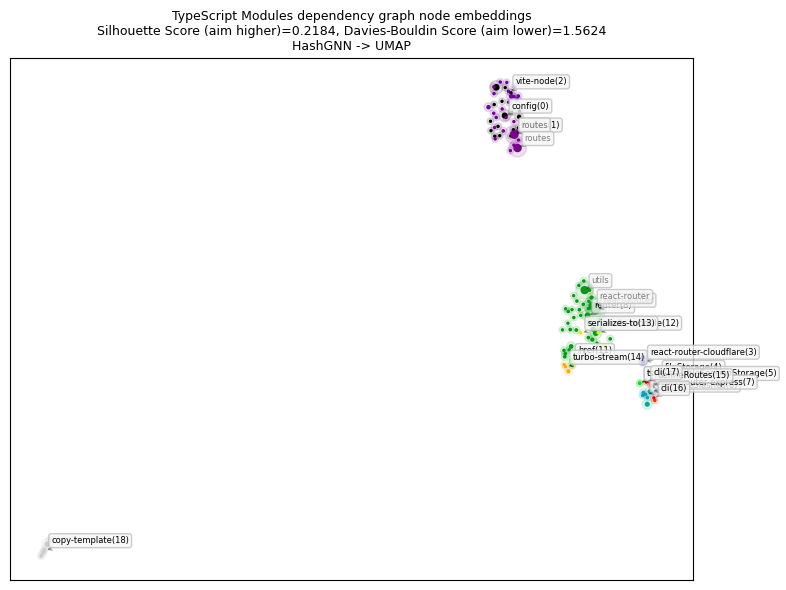

In [26]:
typescript_module_embeddings_parameters={
    **common_projection_parameters,
    "dependencies_projection_write_property": "embeddingsHashGNN",
    "dependencies_projection_embedding_dimension":"32"
}
embeddings_hashGNN = create_node_embeddings("../cypher/Node_Embeddings/Node_Embeddings_2d_Hash_GNN_Stream.cypher", typescript_module_embeddings_parameters)
embeddings_hashGNN = prepare_node_embeddings_for_2d_visualization(embeddings_hashGNN)
scores_hashGNN = CommunityScores.calculate(embeddings_hashGNN)
plot_2d_node_embeddings(embeddings_hashGNN, get_plot_title("TypeScript Modules", "HashGNN", scores_hashGNN))

### 1.6 Node Embeddings for Typescript Modules using node2vec

[node2vec](https://neo4j.com/docs/graph-data-science/current/machine-learning/node-embeddings/node2vec) computes a vector representation of a node based on second order random walks in the graph. 
The [node2vec](https://towardsdatascience.com/complete-guide-to-understanding-node2vec-algorithm-4e9a35e5d147) algorithm is a transductive node embedding algorithm, meaning that it needs the whole graph to be available to learn the node embeddings.

Received notification from DBMS server: {severity: WARNING} {code: Neo.ClientNotification.Statement.UnknownLabelWarning} {category: UNRECOGNIZED} {title: The provided label is not in the database.} {description: One of the labels in your query is not available in the database, make sure you didn't misspell it or that the label is available when you run this statement in your application (the missing label name is: Java)} {position: line: 7, column: 27, offset: 572} for query: '// Query already calculated and written node embeddings on nodes with label in parameter $dependencies_projection_node including a communityId and centrality. Variables: dependencies_projection_node, dependencies_projection_write_property. Requires "Add_file_name and_extension.cypher".\n \n  MATCH (codeUnit)\n  WHERE $dependencies_projection_node IN LABELS(codeUnit)\n    AND codeUnit[$dependencies_projection_write_property] IS NOT NULL\n    // AND codeUnit.notExistingToForceRecalculation IS NOT NULL // uncomment 

Received notification from DBMS server: {severity: WARNING} {code: Neo.ClientNotification.Statement.UnknownPropertyKeyWarning} {category: UNRECOGNIZED} {title: The provided property key is not in the database} {description: One of the property names in your query is not available in the database, make sure you didn't misspell it or that the label is available when you run this statement in your application (the missing property name is: signature)} {position: line: 12, column: 81, offset: 924} for query: '// Query already calculated and written node embeddings on nodes with label in parameter $dependencies_projection_node including a communityId and centrality. Variables: dependencies_projection_node, dependencies_projection_write_property. Requires "Add_file_name and_extension.cypher".\n \n  MATCH (codeUnit)\n  WHERE $dependencies_projection_node IN LABELS(codeUnit)\n    AND codeUnit[$dependencies_projection_write_property] IS NOT NULL\n    // AND codeUnit.notExistingToForceRecalculat

The results have been provided by the query filename: ../cypher/Node_Embeddings/Node_Embeddings_0a_Query_Calculated.cypher


,codeUnitName,shortCodeUnitName,projectName,communityId,centrality,embedding
0,/home/runner/work/code-graph-analysis-examples...,config,react-router-dev,0,1.705838,"[-0.742321789264679, 0.8552514910697937, -0.14..."
1,/home/runner/work/code-graph-analysis-examples...,detectPackageManager,react-router-dev,0,0.188886,"[-0.5732265114784241, 0.617485761642456, -0.03..."
2,/home/runner/work/code-graph-analysis-examples...,config,react-router-dev,0,2.129389,"[-0.8322977423667908, 0.722755491733551, -0.03..."
3,/home/runner/work/code-graph-analysis-examples...,context,react-router-dev,0,0.180345,"[-0.8710538744926453, 0.855966329574585, -0.07..."
4,/home/runner/work/code-graph-analysis-examples...,generate,react-router-dev,0,0.277201,"[-0.7641913294792175, 0.7800344228744507, -0.1..."


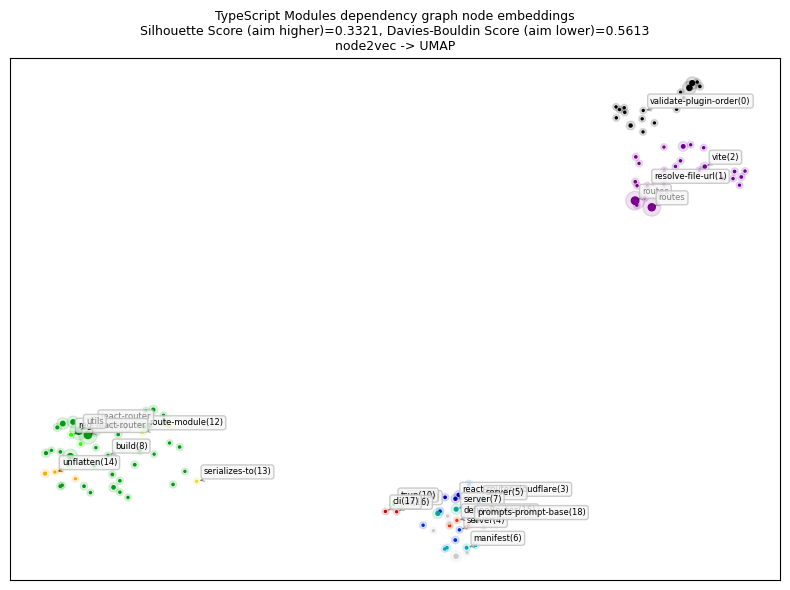

In [27]:
typescript_module_embeddings_parameters={
    **common_projection_parameters,
    "dependencies_projection_write_property": "embeddingsNode2Vec",
    "dependencies_projection_embedding_dimension":"32"
}
embeddings_node2vec = create_node_embeddings("../cypher/Node_Embeddings/Node_Embeddings_3d_Node2Vec_Stream.cypher", typescript_module_embeddings_parameters)
embeddings_node2vec = prepare_node_embeddings_for_2d_visualization(embeddings_node2vec)
scores_node2vec = CommunityScores.calculate(embeddings_node2vec)
plot_2d_node_embeddings(embeddings_node2vec, get_plot_title("TypeScript Modules", "node2vec", scores_node2vec))

### 1.7 Node Embeddings for Java Packages using GraphSAGE

,modelName,didConverge,ranEpochs,epochLosses,trainingTimeMilliseconds
0,typescript-module-embeddings-notebook-graphSAGE,False,1,[33.89941588827657],447


Received notification from DBMS server: {severity: WARNING} {code: Neo.ClientNotification.Statement.UnknownLabelWarning} {category: UNRECOGNIZED} {title: The provided label is not in the database.} {description: One of the labels in your query is not available in the database, make sure you didn't misspell it or that the label is available when you run this statement in your application (the missing label name is: Java)} {position: line: 11, column: 27, offset: 349} for query: '// Node Embeddings 4d using GraphSAGE: Stream. Requires "Add_file_name and_extension.cypher".\n \n CALL gds.beta.graphSage.stream(\n  $dependencies_projection + \'-cleaned\', {\n       modelName: $dependencies_projection + \'-graphSAGE\'\n   }\n )\n YIELD nodeId, embedding\n  WITH gds.util.asNode(nodeId) AS codeUnit\n      ,embedding\n OPTIONAL MATCH (artifact:Java:Artifact)-[:CONTAINS]->(codeUnit)\n    WITH *, artifact.name AS artifactName\n OPTIONAL MATCH (projectRoot:Directory)<-[:HAS_ROOT]-(proj:TS:Project)-

Received notification from DBMS server: {severity: WARNING} {code: Neo.ClientNotification.Statement.UnknownPropertyKeyWarning} {category: UNRECOGNIZED} {title: The provided property key is not in the database} {description: One of the property names in your query is not available in the database, make sure you didn't misspell it or that the label is available when you run this statement in your application (the missing property name is: signature)} {position: line: 16, column: 81, offset: 701} for query: '// Node Embeddings 4d using GraphSAGE: Stream. Requires "Add_file_name and_extension.cypher".\n \n CALL gds.beta.graphSage.stream(\n  $dependencies_projection + \'-cleaned\', {\n       modelName: $dependencies_projection + \'-graphSAGE\'\n   }\n )\n YIELD nodeId, embedding\n  WITH gds.util.asNode(nodeId) AS codeUnit\n      ,embedding\n OPTIONAL MATCH (artifact:Java:Artifact)-[:CONTAINS]->(codeUnit)\n    WITH *, artifact.name AS artifactName\n OPTIONAL MATCH (projectRoot:Directory)<-[:

,codeUnitName,shortCodeUnitName,nodeElementId,projectName,communityId,centrality,embedding
0,/home/runner/work/code-graph-analysis-examples...,config,4:1004ba35-29ba-4262-a3e0-532f38a430b1:10877,react-router-dev,0,1.705838,"[-0.004854696200530722, 0.0380514686146112, 0...."
1,/home/runner/work/code-graph-analysis-examples...,manifest,4:1004ba35-29ba-4262-a3e0-532f38a430b1:10879,react-router-dev,1,0.150390,"[-0.0048546962005307235, 0.03805146861461116, ..."
2,/home/runner/work/code-graph-analysis-examples...,routes,4:1004ba35-29ba-4262-a3e0-532f38a430b1:10880,react-router-dev,1,4.035645,"[-0.004854696200530722, 0.038051468614611214, ..."
3,/home/runner/work/code-graph-analysis-examples...,commands,4:1004ba35-29ba-4262-a3e0-532f38a430b1:10884,react-router-dev,2,0.277500,"[-0.004854696200530722, 0.03805146861461115, 0..."
4,/home/runner/work/code-graph-analysis-examples...,detectPackageManager,4:1004ba35-29ba-4262-a3e0-532f38a430b1:10886,react-router-dev,0,0.188886,"[-0.0048546962005307235, 0.03805146861461118, ..."


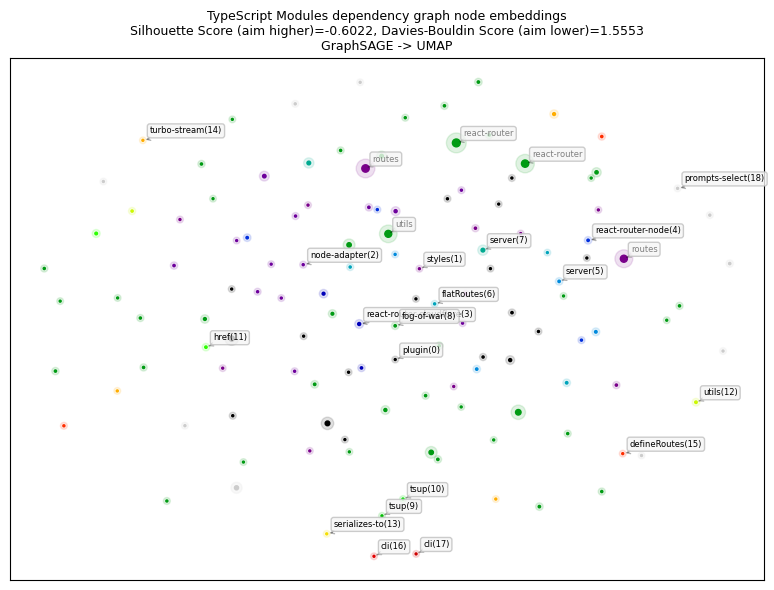

In [28]:
typescript_module_embeddings_parameters={
    **common_projection_parameters,
    "dependencies_projection_write_property": "embeddingsGraphSAGE",
    "dependencies_projection_embedding_dimension":"32"
}
embeddings_graphSAGE= create_node_embeddings_with_GraphSAGE(typescript_module_embeddings_parameters)
embeddings_graphSAGE = prepare_node_embeddings_for_2d_visualization(embeddings_graphSAGE)
scores_graphSAGE = CommunityScores.calculate(embeddings_graphSAGE)
plot_2d_node_embeddings(embeddings_graphSAGE, get_plot_title("TypeScript Modules", "GraphSAGE", scores_graphSAGE))

### 2. Compare Node Embeddings

In this section we will compare all node embedding methods from above in a grid plot. This helps to see how well the different algorithms were able to capture the structure of the graph and how well the communities are separated.

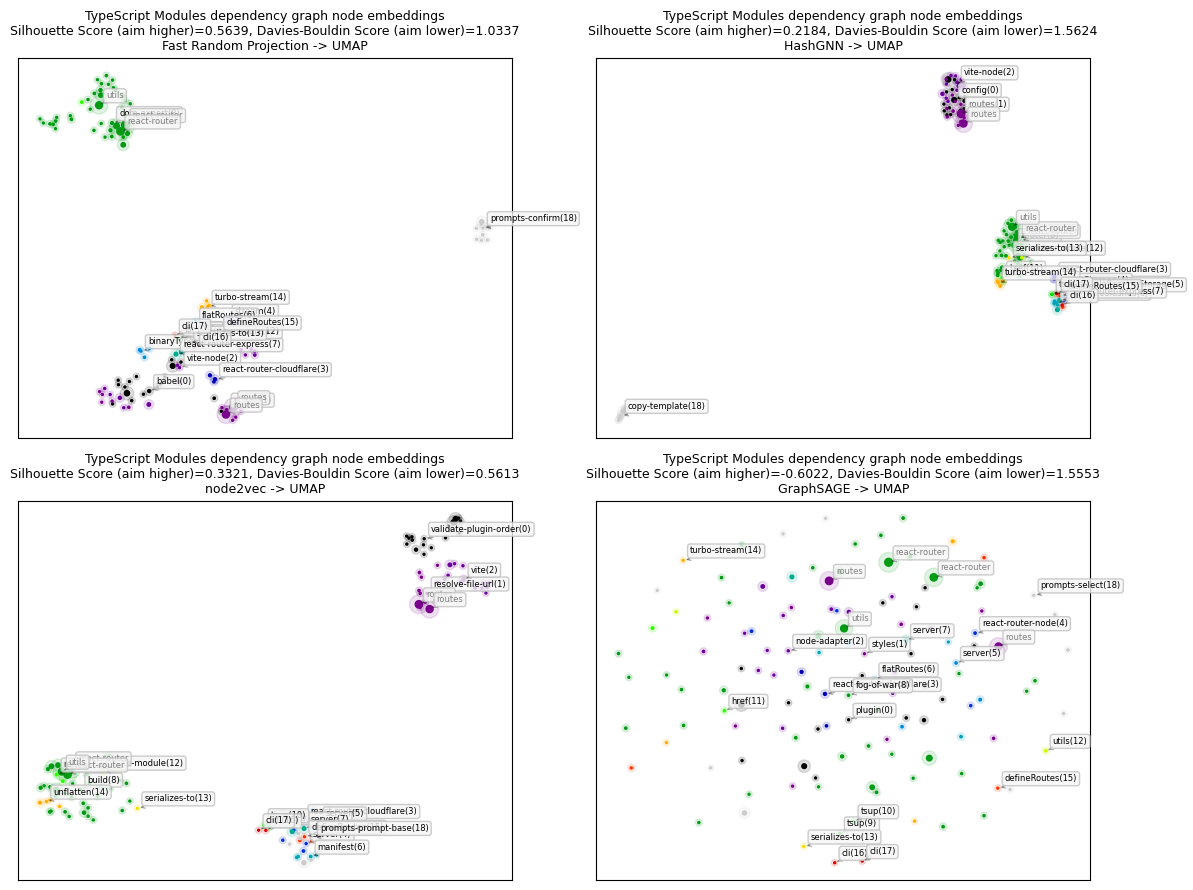

In [29]:
plot_all_2d_node_embeddings_in_grid(
    embeddings=[embeddings_fastRP, embeddings_hashGNN, embeddings_node2vec, embeddings_graphSAGE],
    titles=[
        get_plot_title("TypeScript Modules", "Fast Random Projection", scores_fastRP),
        get_plot_title("TypeScript Modules", "HashGNN", scores_hashGNN),
        get_plot_title("TypeScript Modules", "node2vec", scores_node2vec),
        get_plot_title("TypeScript Modules", "GraphSAGE", scores_graphSAGE),
    ],
)

#### Interpreting Node Embedding Results

##### Summary of Observations

- **FastRP** and **node2vec** show clear, well-separated clusters
- **HashGNN** and **GraphSAGE** produce more diffuse embeddings
- Silhouette scores are high for FastRP / node2vec and low for HashGNN / GraphSAGE

These differences are expected and stem from the **fundamentally different objectives** of the algorithms.

##### Key Takeaways

- **FastRP and node2vec** are well-suited for **community discovery and visualization**
- **HashGNN** is best viewed as a **fast structural fingerprint**, not a clustering embedding
- **GraphSAGE** requires meaningful node features or labels and performs poorly in dense, feature-poor settings
- Poor silhouette scores for HashGNN and GraphSAGE are **expected and theoretically consistent**